# TRANP-CNN Phase 1 Bug Localization Results Analysis

This notebook analyses the Phase 1 experimental results for the TRANP-CNN cross-project bug localization (CPL) pipeline.  
TRANP-CNN reranks a FAISS-retrieved candidate set (top-300) using a neural reranker trained on source/target project data.

**Scenarios evaluated:**
- **WP-small**: within-project, 20% target data for training
- **WP-large**: within-project, 80% target data for training
- **CP-cold-start**: cross-project, 100% source data, zero target data
- **CP-transfer**: cross-project, 100% source + 20% target data

**TOP_K_CANDIDATES = 300** (FAISS retrieval budget)

## Module 0 – Setup & Data Loading

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# ── Constants ──────────────────────────────────────────────────────────────────
TOP_K_CANDIDATES = 300
SCENARIOS = ['WP-small', 'WP-large', 'CP-cold-start', 'CP-transfer']
SCENARIO_COLORS = {
    'WP-small':     '#2196F3',
    'WP-large':     '#4CAF50',
    'CP-cold-start':'#FF9800',
    'CP-transfer':  '#E91E63',
}

# ── Paths ──────────────────────────────────────────────────────────────────────
RESULTS_DIR         = '../results'
IMAGES_DIR          = os.path.join(RESULTS_DIR, 'images')
SUMMARY_CSV         = os.path.join(RESULTS_DIR, 'tranp_cnn_ph1_summary.csv')
BUG_SIM_CSV         = os.path.join(RESULTS_DIR, 'bug_report_similarity.csv')
CODE_SIM_CSV        = os.path.join(RESULTS_DIR, 'code_similarity.csv')
METADATA_PARQUET    = '../data/processed/project_metadata.parquet'
DOMAIN_GAP_CSV      = os.path.join(RESULTS_DIR, 'all_project_domain_gaps.csv')
DIAGNOSTICS_DIR     = os.path.join(RESULTS_DIR, 'tranp_cnn_ph1_diagnostics')

os.makedirs(IMAGES_DIR, exist_ok=True)

print(f'Images will be saved to: {os.path.abspath(IMAGES_DIR)}')

Images will be saved to: /home/cs21d002_eashaan/PhD/Objective1/results/images


In [2]:
# ── Load summary ───────────────────────────────────────────────────────────────
summary = pd.read_csv(SUMMARY_CSV)
print(f'Summary shape: {summary.shape}')

# Ensure scenario column is ordered
summary['scenario'] = pd.Categorical(summary['scenario'], categories=SCENARIOS, ordered=True)
summary['pair_label'] = summary['source_project'] + ' → ' + summary['target_project']

summary.head(3)

Summary shape: (367, 47)


,source_project,target_project,scenario,model_n_bugs,model_top1,model_top5,model_top10,model_mrr,model_mean_rank,model_median_rank,...,tgt_total_unique_bug_reports,tgt_code_complexity,tgt_bug_report_verbosity,tgt_domain,tgt_project_size,tgt_polyglot_index,tgt_bug_density,tgt_age_years,same_domain,pair_label
0,google/jax,matplotlib/matplotlib,CP-cold-start,8,0.0,0.000,0.000,0.003766,266.625,264.5,...,183,2.4,242.684783,Data Science & AI/ML,medium,0.98661,1.359765,4.364134,True,google/jax → matplotlib/matplotlib
1,google/jax,matplotlib/matplotlib,CP-transfer,8,0.0,0.500,0.750,0.201637,8.375,6.0,...,183,2.4,242.684783,Data Science & AI/ML,medium,0.98661,1.359765,4.364134,True,google/jax → matplotlib/matplotlib
2,google/jax,matplotlib/matplotlib,WP-large,8,0.0,0.375,0.625,0.155163,9.500,8.0,...,183,2.4,242.684783,Data Science & AI/ML,medium,0.98661,1.359765,4.364134,True,google/jax → matplotlib/matplotlib


In [3]:
# ── Load bug_report_similarity (optional — may not exist yet) ──────────────────
bug_sim_df = None
try:
    bug_sim_df = pd.read_csv(BUG_SIM_CSV)
    print(f'Bug similarity CSV loaded: {bug_sim_df.shape}')
    print(bug_sim_df.columns.tolist())
except FileNotFoundError:
    print(f'[WARNING] Bug report similarity CSV not found at {BUG_SIM_CSV}. '
          'Bug-similarity features will be skipped.')

# ── Load code_similarity (optional) ───────────────────────────────────────────
code_sim_df = None
try:
    code_sim_df = pd.read_csv(CODE_SIM_CSV)
    print(f'Code similarity CSV loaded: {code_sim_df.shape}')
except FileNotFoundError:
    print(f'[WARNING] Code similarity CSV not found at {CODE_SIM_CSV}. '
          'Code-similarity features will be skipped.')

# ── Load metadata ──────────────────────────────────────────────────────────────
try:
    metadata = pd.read_parquet(METADATA_PARQUET)
    print(f'Metadata shape: {metadata.shape}')
except Exception as e:
    metadata = None
    print(f'[WARNING] Could not load metadata parquet: {e}')

# ── Load domain gap ────────────────────────────────────────────────────────────
try:
    domain_gap_df = pd.read_csv(DOMAIN_GAP_CSV)
    print(f'Domain gap CSV loaded: {domain_gap_df.shape}')
    print(domain_gap_df.head(3))
except FileNotFoundError:
    domain_gap_df = None
    print(f'[WARNING] Domain gap CSV not found at {DOMAIN_GAP_CSV}.')

Bug similarity CSV loaded: (47, 7)
['project_A', 'project_B', 'n_bugs_A', 'n_bugs_B', 'mean_sim', 'std_sim', 'median_sim']
Code similarity CSV loaded: (47, 7)
Metadata shape: (98, 18)
Domain gap CSV loaded: (4753, 7)
      project_A        project_B lang_A lang_B  num_bugs_A  num_bugs_B  \
0  apache/camel     apache/hbase   Java   Java        1469         838   
1  apache/camel      apache/hive   Java   Java        1469        1238   
2  apache/camel  wildfly/wildfly   Java   Java        1469         984   

   domain_gap_accuracy  
0             0.995569  
1             0.995763  
2             0.989229  


In [4]:
# ── Merge bug_sim and code_sim into summary ───────────────────────────────────
def make_sorted_pair_key(df, col_a, col_b):
    """Create a canonical (alphabetically sorted) pair key for join."""
    pairs = df[[col_a, col_b]].apply(
        lambda row: tuple(sorted([row[col_a], row[col_b]])), axis=1
    )
    return pairs.apply(lambda t: f'{t[0]}||{t[1]}')

summary['_pair_key'] = make_sorted_pair_key(summary, 'source_project', 'target_project')

# Bug sim merge
if bug_sim_df is not None:
    # Detect project columns in bug_sim_df (try common names)
    possible_a = [c for c in bug_sim_df.columns if 'project' in c.lower() or 'src' in c.lower() or 'proj_a' in c.lower()]
    possible_b = [c for c in bug_sim_df.columns if 'project' in c.lower() or 'tgt' in c.lower() or 'proj_b' in c.lower()]
    sim_col    = [c for c in bug_sim_df.columns if 'sim' in c.lower() or 'mean' in c.lower()]
    print('Bug sim columns:', bug_sim_df.columns.tolist())
    if len(possible_a) >= 2:
        col_a_sim, col_b_sim = possible_a[0], possible_b[-1] if possible_b else possible_a[1]
    else:
        col_a_sim, col_b_sim = bug_sim_df.columns[0], bug_sim_df.columns[1]
    bug_sim_col = sim_col[0] if sim_col else bug_sim_df.columns[2]
    bug_sim_df['_pair_key'] = make_sorted_pair_key(bug_sim_df, col_a_sim, col_b_sim)
    pair_bug_sim = bug_sim_df.groupby('_pair_key')[bug_sim_col].mean().reset_index()
    pair_bug_sim.columns = ['_pair_key', 'bug_sim']
    summary = summary.merge(pair_bug_sim, on='_pair_key', how='left')
    print(f'Merged bug_sim: {summary["bug_sim"].notna().sum()} rows have values')
else:
    summary['bug_sim'] = np.nan

# Code sim merge
if code_sim_df is not None:
    sim_col_c = [c for c in code_sim_df.columns if 'sim' in c.lower() or 'mean' in c.lower()]
    col_a_c = code_sim_df.columns[0]
    col_b_c = code_sim_df.columns[1]
    code_sim_col = sim_col_c[0] if sim_col_c else code_sim_df.columns[2]
    code_sim_df['_pair_key'] = make_sorted_pair_key(code_sim_df, col_a_c, col_b_c)
    pair_code_sim = code_sim_df.groupby('_pair_key')[code_sim_col].mean().reset_index()
    pair_code_sim.columns = ['_pair_key', 'code_sim']
    summary = summary.merge(pair_code_sim, on='_pair_key', how='left')
    print(f'Merged code_sim: {summary["code_sim"].notna().sum()} rows have values')
else:
    summary['code_sim'] = np.nan

# Summary statistics
n_pairs    = summary['pair_label'].nunique()
n_rows     = len(summary)
n_scenarios = summary['scenario'].nunique()
print(f'\nUnique project pairs : {n_pairs}')
print(f'Total rows           : {n_rows}')
print(f'Scenarios present    : {n_scenarios}')
summary.head(4)

Bug sim columns: ['project_A', 'project_B', 'n_bugs_A', 'n_bugs_B', 'mean_sim', 'std_sim', 'median_sim']
Merged bug_sim: 367 rows have values
Merged code_sim: 367 rows have values

Unique project pairs : 92
Total rows           : 367
Scenarios present    : 4


,source_project,target_project,scenario,model_n_bugs,model_top1,model_top5,model_top10,model_mrr,model_mean_rank,model_median_rank,...,tgt_domain,tgt_project_size,tgt_polyglot_index,tgt_bug_density,tgt_age_years,same_domain,pair_label,_pair_key,bug_sim,code_sim
0,google/jax,matplotlib/matplotlib,CP-cold-start,8,0.000,0.000,0.000,0.003766,266.625,264.5,...,Data Science & AI/ML,medium,0.98661,1.359765,4.364134,True,google/jax → matplotlib/matplotlib,google/jax||matplotlib/matplotlib,0.409185,0.330433
1,google/jax,matplotlib/matplotlib,CP-transfer,8,0.000,0.500,0.750,0.201637,8.375,6.0,...,Data Science & AI/ML,medium,0.98661,1.359765,4.364134,True,google/jax → matplotlib/matplotlib,google/jax||matplotlib/matplotlib,0.409185,0.330433
2,google/jax,matplotlib/matplotlib,WP-large,8,0.000,0.375,0.625,0.155163,9.500,8.0,...,Data Science & AI/ML,medium,0.98661,1.359765,4.364134,True,google/jax → matplotlib/matplotlib,google/jax||matplotlib/matplotlib,0.409185,0.330433
3,google/jax,matplotlib/matplotlib,WP-small,8,0.125,0.500,0.875,0.336607,5.625,5.5,...,Data Science & AI/ML,medium,0.98661,1.359765,4.364134,True,google/jax → matplotlib/matplotlib,google/jax||matplotlib/matplotlib,0.409185,0.330433


## Module 1 – Scenario Performance Overview

In [5]:
# ── Mean metrics per scenario (model vs FAISS baseline) ───────────────────────
metric_cols = ['model_top1', 'model_top5', 'model_top10', 'model_mrr',
               'faiss_top1', 'faiss_top5', 'faiss_top10', 'faiss_mrr']

perf_table = (summary.groupby('scenario', observed=True)[metric_cols]
                      .mean()
                      .round(4)
                      .reindex(SCENARIOS))

print('=== Mean performance per scenario ===')
display(perf_table)

=== Mean performance per scenario ===


,model_top1,model_top5,model_top10,model_mrr,faiss_top1,faiss_top5,faiss_top10,faiss_mrr
scenario,,,,,,,,
WP-small,0.0614,0.2158,0.3316,0.1468,0.0002,0.0070,0.0324,0.0157
WP-large,0.0715,0.2750,0.3936,0.1791,0.0002,0.0070,0.0324,0.0157
CP-cold-start,0.0068,0.0329,0.0628,0.0328,0.0002,0.0074,0.0328,0.0158
CP-transfer,0.0671,0.2436,0.3724,0.1643,0.0002,0.0071,0.0315,0.0156


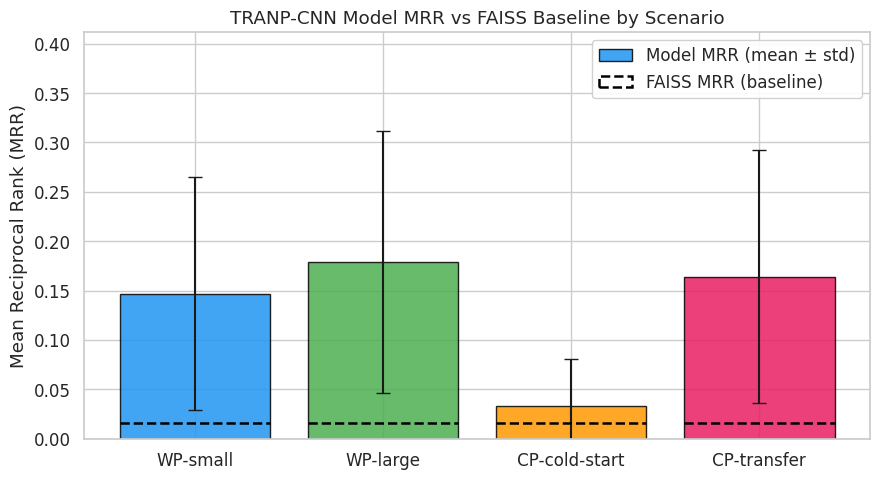

In [6]:
# ── Bar chart: mean model MRR ± std per scenario, with FAISS MRR dashed line ──
mrr_stats = (summary.groupby('scenario', observed=True)['model_mrr']
                    .agg(['mean', 'std'])
                    .reindex(SCENARIOS))
faiss_mrr_mean = (summary.groupby('scenario', observed=True)['faiss_mrr']
                         .mean()
                         .reindex(SCENARIOS))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(SCENARIOS))
bars = ax.bar(
    x,
    mrr_stats['mean'],
    yerr=mrr_stats['std'],
    capsize=5,
    color=[SCENARIO_COLORS[s] for s in SCENARIOS],
    edgecolor='black',
    alpha=0.85,
    label='Model MRR (mean ± std)'
)
for i, s in enumerate(SCENARIOS):
    ax.hlines(
        faiss_mrr_mean[s], i - 0.4, i + 0.4,
        colors='black', linestyles='--', linewidth=1.8
    )

# Legend proxy for dashed line
faiss_proxy = mpatches.Patch(facecolor='none', edgecolor='black',
                              label='FAISS MRR (baseline)', linestyle='--', linewidth=1.8)
ax.legend(handles=[bars, faiss_proxy], loc='upper right', framealpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(SCENARIOS)
ax.set_ylabel('Mean Reciprocal Rank (MRR)')
ax.set_title('TRANP-CNN Model MRR vs FAISS Baseline by Scenario')
ax.set_ylim(0, min(1.0, mrr_stats['mean'].max() + mrr_stats['std'].max() + 0.1))
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'mod1_mrr_by_scenario.png'), dpi=150)
plt.show()

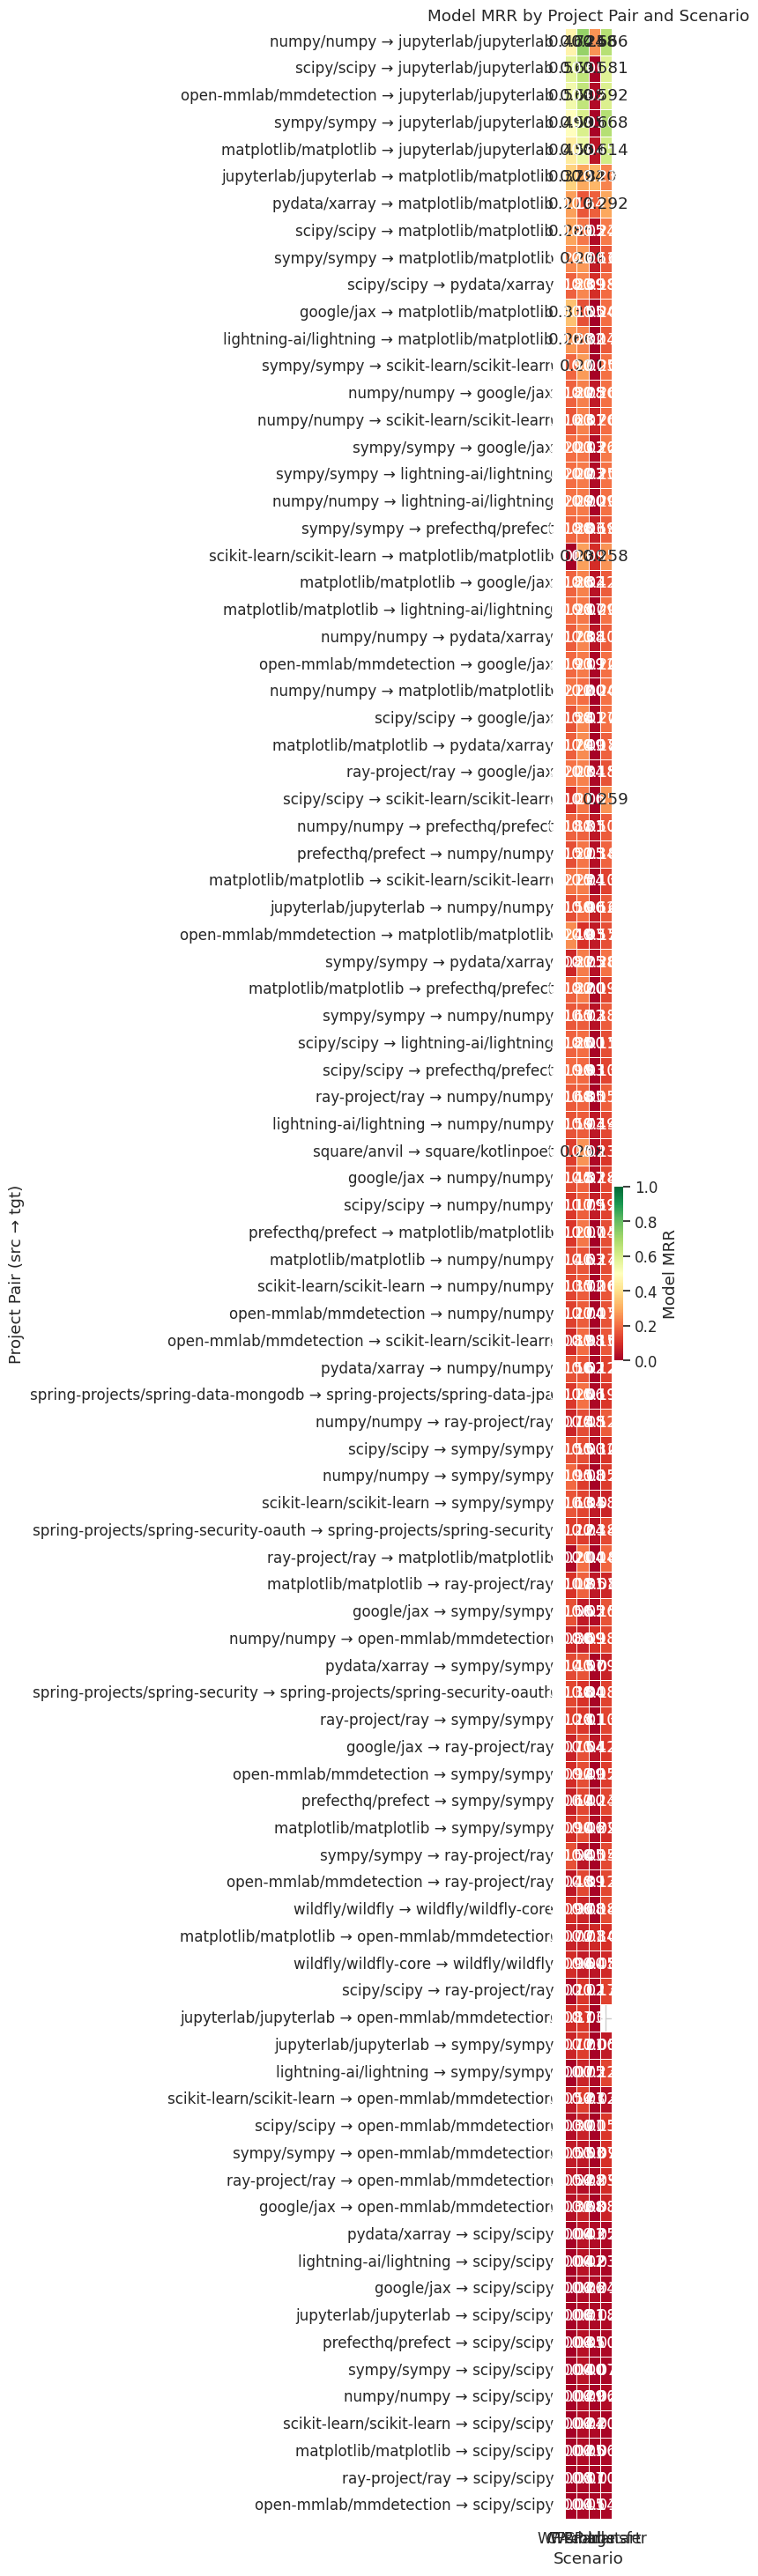

In [7]:
# ── Heatmap: pairs × scenarios, colour = model_mrr ────────────────────────────
hm_data = (summary.pivot_table(index='pair_label', columns='scenario',
                                values='model_mrr', observed=True)
                  .reindex(columns=SCENARIOS))

# Sort by mean MRR descending
hm_data = hm_data.loc[hm_data.mean(axis=1).sort_values(ascending=False).index]

fig_h  = max(6, len(hm_data) * 0.32)
fig, ax = plt.subplots(figsize=(8, fig_h))
sns.heatmap(
    hm_data,
    annot=True, fmt='.3f', cmap='RdYlGn',
    linewidths=0.4, ax=ax,
    vmin=0.0, vmax=1.0,
    cbar_kws={'label': 'Model MRR'}
)
ax.set_title('Model MRR by Project Pair and Scenario')
ax.set_xlabel('Scenario')
ax.set_ylabel('Project Pair (src → tgt)')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'mod1_mrr_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### Observations – Module 1

**Expected ranking:** WP-large > CP-transfer > WP-small > CP-cold-start

- WP-large should be the ceiling — the model sees the most target-project data.
- CP-transfer (source + 20% target) should sit between the WP variants because it benefits from transfer but has less target data than WP-large.
- WP-small is the weakest within-project baseline, limited to 20% target data.
- CP-cold-start is expected lowest: no target data, relies entirely on the source-project model.

**Exceptions to investigate:**
- Any pair/scenario where CP-cold-start beats WP-small suggests strong domain alignment or sparse target data.
- Any pair where CP-transfer beats WP-large is direct evidence that cross-project transfer adds value beyond more within-project data.

## Module 2 – WP-large vs CP-transfer (CPL Feasibility Evidence)

In [8]:
# ── Pivot to wide format for easy comparison ───────────────────────────────────
wide = summary.pivot_table(
    index='pair_label', columns='scenario',
    values=['model_mrr', 'faiss_mrr', 'pct_model_improved', 'mean_displacement'],
    observed=True
)
wide.columns = ['_'.join(c).strip() for c in wide.columns]
wide = wide.reset_index()

# Merge same_domain and domain_gap (take from any scenario — they are pair-level)
pair_meta = (summary.drop_duplicates('pair_label')
                    [['pair_label', 'same_domain', 'domain_gap', 'bug_sim', 'code_sim',
                      'tgt_total_unique_bug_reports', 'src_total_unique_bug_reports']]
                    .copy())
wide = wide.merge(pair_meta, on='pair_label', how='left')

print(f'Wide table shape: {wide.shape}')
wide.head(3)

Wide table shape: (92, 23)


,pair_label,faiss_mrr_WP-small,faiss_mrr_WP-large,faiss_mrr_CP-cold-start,faiss_mrr_CP-transfer,mean_displacement_WP-small,mean_displacement_WP-large,mean_displacement_CP-cold-start,mean_displacement_CP-transfer,model_mrr_WP-small,...,pct_model_improved_WP-small,pct_model_improved_WP-large,pct_model_improved_CP-cold-start,pct_model_improved_CP-transfer,same_domain,domain_gap,bug_sim,code_sim,tgt_total_unique_bug_reports,src_total_unique_bug_reports
0,google/jax → matplotlib/matplotlib,0.008809,0.008809,0.008809,0.008809,175.250000,171.375000,-85.750000,172.500000,0.336607,...,1.000000,1.000000,0.375000,1.000000,True,0.994558,0.409185,0.330433,183,326
1,google/jax → numpy/numpy,0.016413,0.016413,0.016413,0.016413,136.081967,141.377049,58.729508,135.959016,0.145265,...,0.909836,0.918033,0.704918,0.893443,True,0.992608,0.423338,0.413689,789,326
2,google/jax → open-mmlab/mmdetection,0.028130,0.028130,0.028130,0.028130,38.117647,69.882353,-74.470588,55.588235,0.031929,...,0.647059,0.588235,0.411765,0.588235,True,0.995510,0.401529,0.344603,102,326


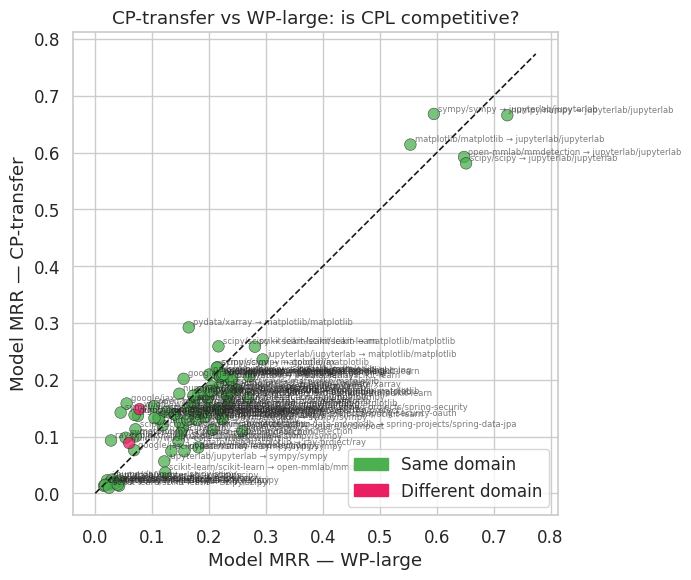

In [9]:
# ── Scatter: model_mrr(WP-large) vs model_mrr(CP-transfer) ────────────────────
col_wpl  = 'model_mrr_WP-large'
col_cpt  = 'model_mrr_CP-transfer'
col_wps  = 'model_mrr_WP-small'

plot_df = wide.dropna(subset=[col_wpl, col_cpt])

fig, ax = plt.subplots(figsize=(7, 6))
colors = plot_df['same_domain'].map({True: '#4CAF50', False: '#E91E63', 1: '#4CAF50', 0: '#E91E63'})
ax.scatter(plot_df[col_wpl], plot_df[col_cpt], c=colors, alpha=0.75, s=70, edgecolors='k', linewidths=0.4)
lim = max(plot_df[[col_wpl, col_cpt]].max().max() + 0.05, 0.1)
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Diagonal (equal)')
for _, row in plot_df.iterrows():
    ax.annotate(row['pair_label'], (row[col_wpl], row[col_cpt]),
                fontsize=6, alpha=0.6, textcoords='offset points', xytext=(3, 2))
green_patch = mpatches.Patch(color='#4CAF50', label='Same domain')
pink_patch  = mpatches.Patch(color='#E91E63', label='Different domain')
ax.legend(handles=[green_patch, pink_patch], loc='lower right')
ax.set_xlabel('Model MRR — WP-large')
ax.set_ylabel('Model MRR — CP-transfer')
ax.set_title('CP-transfer vs WP-large: is CPL competitive?')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'mod2_cpt_vs_wpl_scatter.png'), dpi=150)
plt.show()

In [10]:
# ── Key CPL statistics ────────────────────────────────────────────────────────
if col_wps in wide.columns and col_cpt in wide.columns:
    cpt_beats_wps = (wide[col_cpt] > wide[col_wps]).sum()
    total_pairs   = wide[[col_cpt, col_wps]].dropna().shape[0]
    pct_cpt_beats_wps = 100 * cpt_beats_wps / total_pairs
    print(f'CP-transfer > WP-small: {cpt_beats_wps}/{total_pairs} pairs ({pct_cpt_beats_wps:.1f}%)  ← key CPL argument')

if col_wpl in wide.columns and col_cpt in wide.columns:
    cpt_ge_wpl = (wide[col_cpt] >= wide[col_wpl]).sum()
    total_both = wide[[col_cpt, col_wpl]].dropna().shape[0]
    pct_cpt_ge_wpl = 100 * cpt_ge_wpl / total_both
    print(f'CP-transfer >= WP-large: {cpt_ge_wpl}/{total_both} pairs ({pct_cpt_ge_wpl:.1f}%)')

CP-transfer > WP-small: 60/91 pairs (65.9%)  ← key CPL argument
CP-transfer >= WP-large: 27/91 pairs (29.7%)


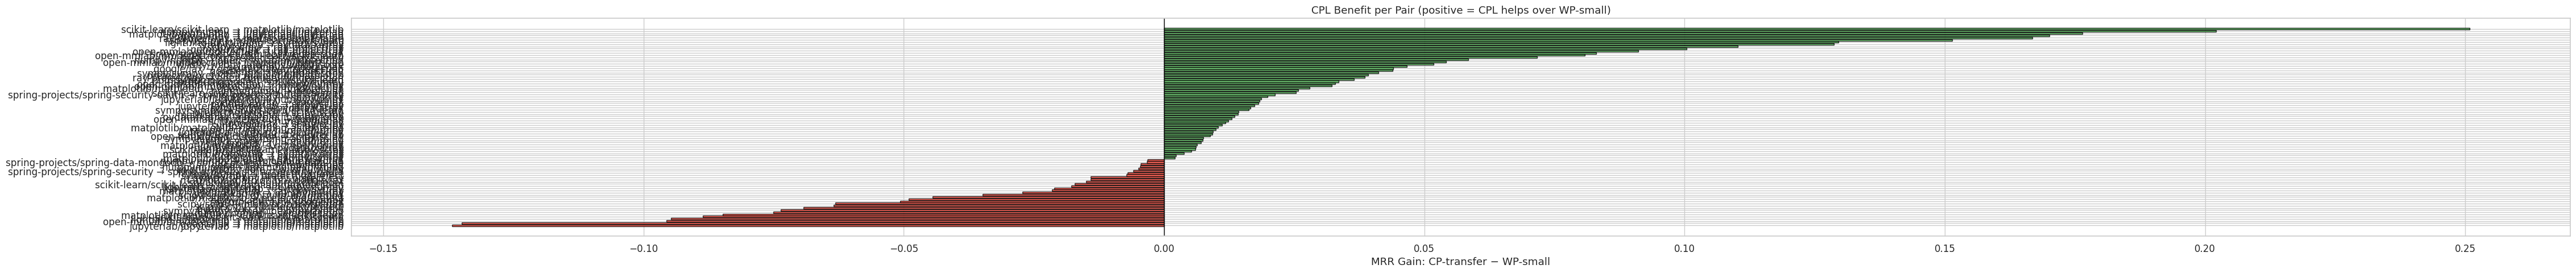

In [11]:
# ── Bar chart: MRR gap = CP-transfer minus WP-small ───────────────────────────
wide['mrr_gap_cpt_vs_wps'] = wide[col_cpt] - wide[col_wps]
gap_df = wide[['pair_label', 'mrr_gap_cpt_vs_wps']].dropna().sort_values('mrr_gap_cpt_vs_wps')

fig, ax = plt.subplots(figsize=(max(8, len(gap_df) * 0.5), 5))
bar_colors = ['#4CAF50' if v >= 0 else '#F44336' for v in gap_df['mrr_gap_cpt_vs_wps']]
ax.barh(gap_df['pair_label'], gap_df['mrr_gap_cpt_vs_wps'], color=bar_colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=1.0)
ax.set_xlabel('MRR Gain: CP-transfer − WP-small')
ax.set_title('CPL Benefit per Pair (positive = CPL helps over WP-small)')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'mod2_mrr_gap_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

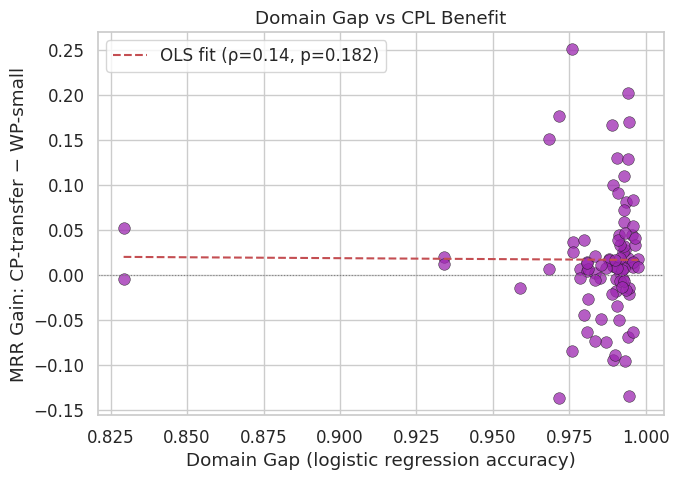

Spearman ρ = 0.141, p = 0.1821


In [12]:
# ── Scatter: domain_gap vs MRR gain (CP-transfer - WP-small) ─────────────────
scatter_df = wide[['pair_label', 'domain_gap', 'mrr_gap_cpt_vs_wps']].dropna()

if len(scatter_df) > 0:
    r, p = stats.spearmanr(scatter_df['domain_gap'], scatter_df['mrr_gap_cpt_vs_wps'])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(scatter_df['domain_gap'], scatter_df['mrr_gap_cpt_vs_wps'],
               alpha=0.75, s=70, color='#9C27B0', edgecolors='k', linewidths=0.4)
    # Regression line
    m, b = np.polyfit(scatter_df['domain_gap'], scatter_df['mrr_gap_cpt_vs_wps'], 1)
    xs = np.linspace(scatter_df['domain_gap'].min(), scatter_df['domain_gap'].max(), 100)
    ax.plot(xs, m * xs + b, 'r--', linewidth=1.5, label=f'OLS fit (ρ={r:.2f}, p={p:.3f})')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Domain Gap (logistic regression accuracy)')
    ax.set_ylabel('MRR Gain: CP-transfer − WP-small')
    ax.set_title('Domain Gap vs CPL Benefit')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod2_domain_gap_vs_gain.png'), dpi=150)
    plt.show()
    print(f'Spearman ρ = {r:.3f}, p = {p:.4f}')
else:
    print('[SKIP] Not enough data for domain_gap scatter (domain_gap column may be missing).')

### Module 2 Key Findings

- The bar chart above shows which project pairs benefit from CPL (green = positive gain, red = negative).
- A positive MRR gain for CP-transfer over WP-small is direct evidence that cross-project data helps when within-project data is scarce.
- The domain gap scatter tests the hypothesis that **low domain gap → CPL helps more**: if the Spearman ρ is negative, smaller gaps correspond to larger gains, supporting the hypothesis.
- A positive ρ would instead suggest that even across very different domains the model finds useful signals, which would be a stronger argument for CPL generality.

## Module 3 – FAISS Ceiling vs TRANP-CNN Architecture

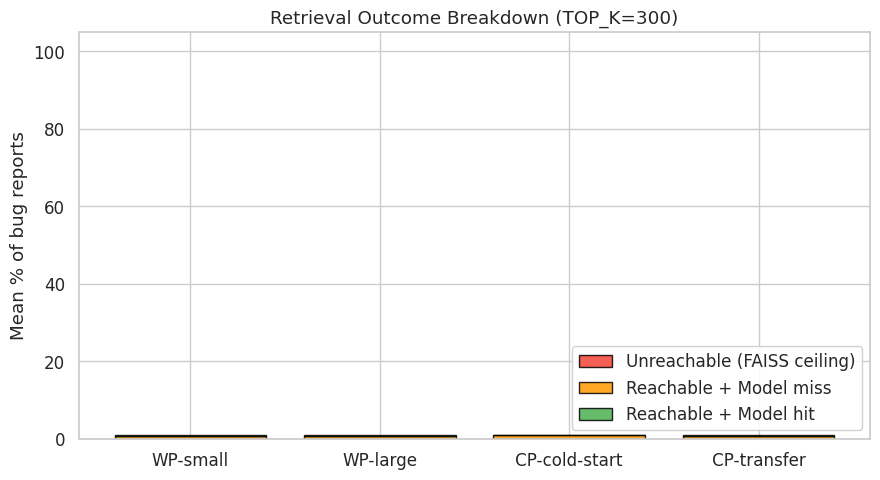

Overall mean pct_unreachable across all scenarios: 0.00%
This is the effective FAISS retrieval ceiling for TRANP-CNN.


In [13]:
# ── Stacked bar: per-scenario breakdown of retrieval outcomes ─────────────────
# Columns: pct_unreachable, pct_reachable_model_hit, pct_reachable_model_miss
seg_cols = ['pct_unreachable', 'pct_reachable_model_miss', 'pct_reachable_model_hit']
seg_colors = ['#F44336', '#FF9800', '#4CAF50']
seg_labels = ['Unreachable (FAISS ceiling)', 'Reachable + Model miss', 'Reachable + Model hit']

# Check columns are present
available_seg = [c for c in seg_cols if c in summary.columns]

if len(available_seg) == 3:
    seg_means = (summary.groupby('scenario', observed=True)[seg_cols]
                        .mean()
                        .reindex(SCENARIOS))

    fig, ax = plt.subplots(figsize=(9, 5))
    bottom = np.zeros(len(SCENARIOS))
    x = np.arange(len(SCENARIOS))
    for col, color, label in zip(seg_cols, seg_colors, seg_labels):
        vals = seg_means[col].fillna(0).values
        ax.bar(x, vals, bottom=bottom, color=color, label=label, edgecolor='black', alpha=0.85)
        # Annotate percentage
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 2:
                ax.text(i, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(SCENARIOS)
    ax.set_ylabel('Mean % of bug reports')
    ax.set_title(f'Retrieval Outcome Breakdown (TOP_K={TOP_K_CANDIDATES})')
    ax.legend(loc='lower right', framealpha=0.9)
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod3_stacked_outcomes.png'), dpi=150)
    plt.show()

    # Overall unreachable
    overall_unreachable = summary['pct_unreachable'].mean()
    print(f'Overall mean pct_unreachable across all scenarios: {overall_unreachable:.2f}%')
    print('This is the effective FAISS retrieval ceiling for TRANP-CNN.')
else:
    print(f'[SKIP] Missing columns for stacked bar. Found: {available_seg}')

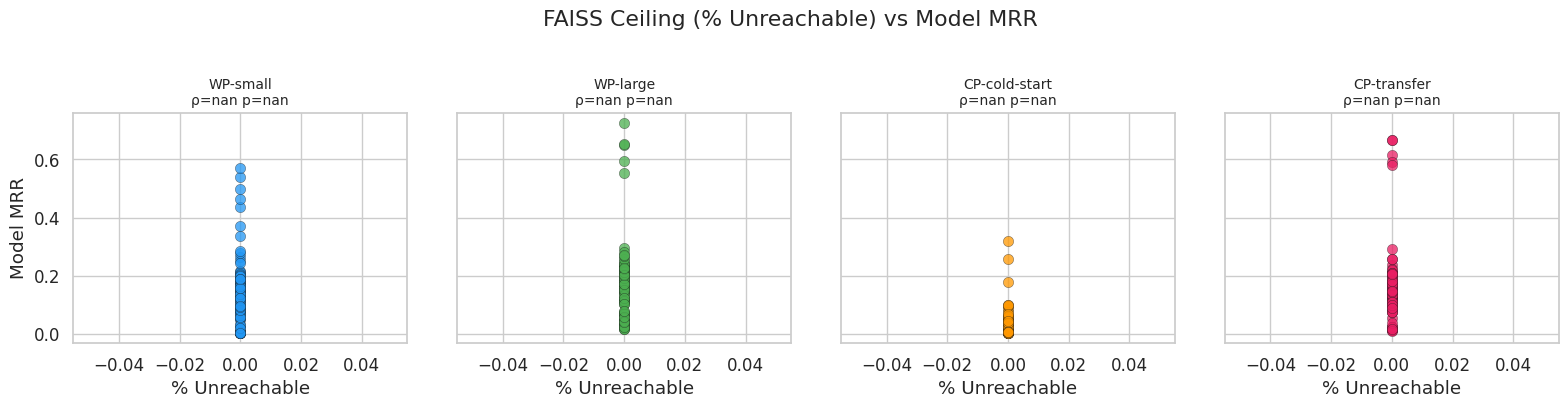

In [14]:
# ── Scatter: pct_unreachable vs model_mrr ─────────────────────────────────────
if 'pct_unreachable' in summary.columns:
    fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(4 * len(SCENARIOS), 4), sharey=True)
    for ax, scen in zip(axes, SCENARIOS):
        sub = summary[summary['scenario'] == scen].dropna(subset=['pct_unreachable', 'model_mrr'])
        if len(sub) > 1:
            r, p = stats.spearmanr(sub['pct_unreachable'], sub['model_mrr'])
            ax.scatter(sub['pct_unreachable'], sub['model_mrr'],
                       color=SCENARIO_COLORS[scen], alpha=0.75, s=55, edgecolors='k', linewidths=0.3)
            ax.set_title(f'{scen}\nρ={r:.2f} p={p:.3f}', fontsize=10)
        ax.set_xlabel('% Unreachable')
        if ax == axes[0]:
            ax.set_ylabel('Model MRR')
    plt.suptitle('FAISS Ceiling (% Unreachable) vs Model MRR', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod3_unreachable_vs_mrr.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Module 3 Diagnostic Interpretation

The three segments of the stacked bar chart separate two distinct failure modes:

1. **Unreachable (red):** The ground-truth file was never in FAISS top-300. No amount of TRANP-CNN reranking can fix this — the embedding/retrieval layer must be improved (better chunk size, better model, BM25 hybrid).

2. **Reachable + Model miss (orange):** FAISS retrieved the file but TRANP-CNN ranked it outside top-K. This points to a failure in the neural reranker — more training data, better architecture, or better features could help.

3. **Reachable + Model hit (green):** FAISS retrieved the file AND TRANP-CNN surfaced it in top-K. This is the success bucket.

A large red segment means the bottleneck is retrieval; a large orange segment means the bottleneck is reranking.

Found 367 diagnostics files.


Total diagnostic rows loaded: 23,772


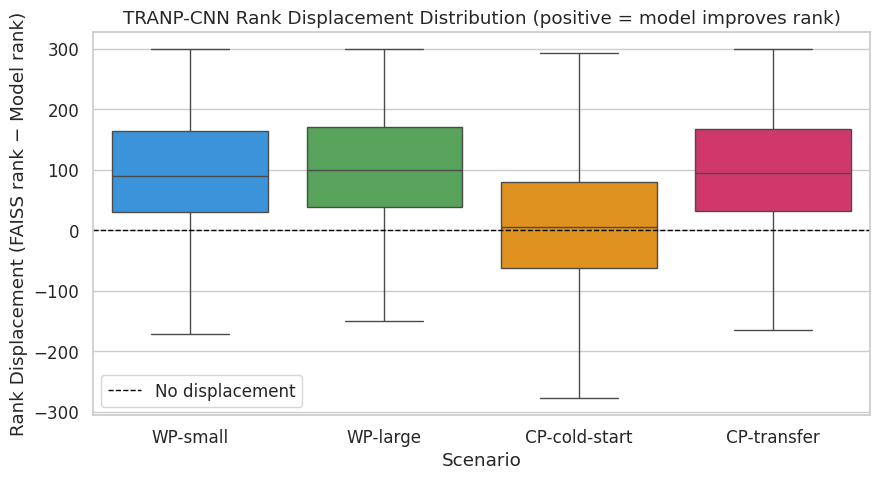

,count,mean,std,min,25%,50%,75%,max
scenario,,,,,,,,
WP-small,5851.0,94.10,93.61,-260.0,30.0,89.0,164.0,299.0
WP-large,5851.0,104.51,88.72,-258.0,38.0,99.0,170.5,299.0
CP-cold-start,6236.0,9.09,109.74,-287.0,-63.0,5.0,80.0,295.0
CP-transfer,5834.0,98.10,93.16,-249.0,31.0,94.0,167.0,299.0


In [15]:
# ── Box plot: rank_displacement distribution per scenario ─────────────────────
# Load a sample of raw diagnostics CSVs
diag_files = glob.glob(os.path.join(DIAGNOSTICS_DIR, '*_diagnostics.csv'))
print(f'Found {len(diag_files)} diagnostics files.')

diag_dfs = []
for fpath in diag_files:
    fname = os.path.basename(fpath)
    # Extract scenario from filename: last part before _diagnostics.csv
    parts = fname.replace('_diagnostics.csv', '').split('_')
    scenario_tag = None
    for scen in SCENARIOS:
        if scen in fname:
            scenario_tag = scen
            break
    try:
        df = pd.read_csv(fpath, usecols=['bug_id', 'faiss_rank', 'model_rank', 'rank_displacement'])
        df['scenario'] = scenario_tag
        diag_dfs.append(df)
    except Exception as e:
        pass  # skip malformed files

if diag_dfs:
    diag_all = pd.concat(diag_dfs, ignore_index=True)
    diag_all['scenario'] = pd.Categorical(diag_all['scenario'], categories=SCENARIOS, ordered=True)
    diag_valid = diag_all.dropna(subset=['rank_displacement', 'scenario'])
    print(f'Total diagnostic rows loaded: {len(diag_valid):,}')

    fig, ax = plt.subplots(figsize=(9, 5))
    palette = {s: SCENARIO_COLORS[s] for s in SCENARIOS if s in diag_valid['scenario'].unique()}
    sns.boxplot(
        data=diag_valid, x='scenario', y='rank_displacement',
        palette=palette, order=SCENARIOS,
        showfliers=False, ax=ax
    )
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--', label='No displacement')
    ax.set_xlabel('Scenario')
    ax.set_ylabel('Rank Displacement (FAISS rank − Model rank)')
    ax.set_title('TRANP-CNN Rank Displacement Distribution (positive = model improves rank)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod3_rank_displacement_boxplot.png'), dpi=150)
    plt.show()

    disp_stats = (diag_valid.groupby('scenario', observed=True)['rank_displacement']
                            .describe(percentiles=[0.25, 0.5, 0.75])
                            .reindex(SCENARIOS)
                            .round(2))
    display(disp_stats)
else:
    print('[SKIP] No diagnostics files could be loaded.')

## Module 4 – Commutativity Analysis

In [16]:
# ── Build symmetric pairs dataframe ───────────────────────────────────────────
# For each pair where both A→B and B→A exist, compute MRR_AB and MRR_BA

rows = []
for scen in SCENARIOS:
    sub = summary[summary['scenario'] == scen][['source_project', 'target_project',
                                                 'model_mrr', 'bug_sim', 'domain_gap',
                                                 'tgt_total_unique_bug_reports']].copy()
    # Build lookup: (src, tgt) → mrr
    lookup = {(row['source_project'], row['target_project']): row['model_mrr']
              for _, row in sub.iterrows()}
    for (a, b), mrr_ab in lookup.items():
        if (b, a) in lookup:
            mrr_ba = lookup[(b, a)]
            rows.append({
                'project_a': a, 'project_b': b,
                'pair_ab': f'{a} → {b}',
                'pair_ba': f'{b} → {a}',
                'canonical_pair': '||'.join(sorted([a, b])),
                'scenario': scen,
                'mrr_ab': mrr_ab,
                'mrr_ba': mrr_ba,
                'asymmetry_score': abs(mrr_ab - mrr_ba),
            })

sym_df = pd.DataFrame(rows).drop_duplicates(subset=['canonical_pair', 'scenario'])
sym_df['scenario'] = pd.Categorical(sym_df['scenario'], categories=SCENARIOS, ordered=True)
print(f'Symmetric pairs found: {sym_df["canonical_pair"].nunique()} unique pairs × {sym_df["scenario"].nunique()} scenarios = {len(sym_df)} rows')
sym_df.head(3)

Symmetric pairs found: 45 unique pairs × 4 scenarios = 179 rows


,project_a,project_b,pair_ab,pair_ba,canonical_pair,scenario,mrr_ab,mrr_ba,asymmetry_score
0,google/jax,matplotlib/matplotlib,google/jax → matplotlib/matplotlib,matplotlib/matplotlib → google/jax,google/jax||matplotlib/matplotlib,WP-small,0.336607,0.186482,0.150125
1,google/jax,numpy/numpy,google/jax → numpy/numpy,numpy/numpy → google/jax,google/jax||numpy/numpy,WP-small,0.145265,0.179926,0.034662
2,google/jax,open-mmlab/mmdetection,google/jax → open-mmlab/mmdetection,open-mmlab/mmdetection → google/jax,google/jax||open-mmlab/mmdetection,WP-small,0.031929,0.193453,0.161524


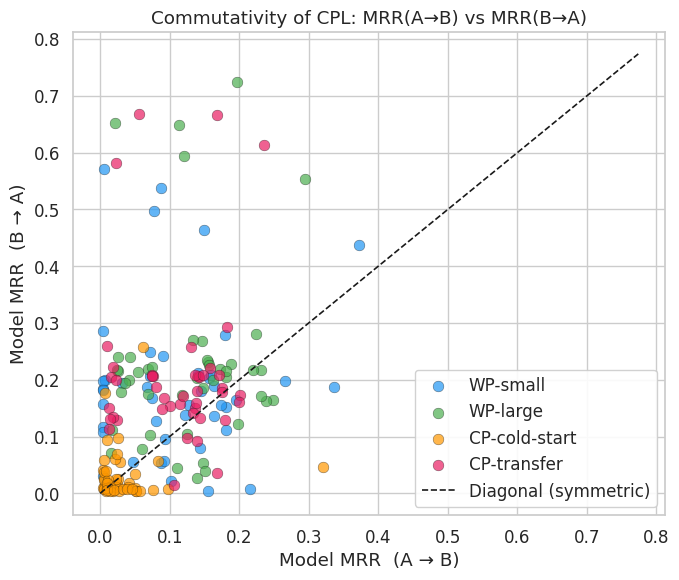

In [17]:
# ── Scatter: MRR(A→B) vs MRR(B→A) coloured by scenario ───────────────────────
if len(sym_df) > 0:
    fig, ax = plt.subplots(figsize=(7, 6))
    for scen in SCENARIOS:
        sub = sym_df[sym_df['scenario'] == scen]
        if len(sub) == 0:
            continue
        ax.scatter(sub['mrr_ab'], sub['mrr_ba'],
                   color=SCENARIO_COLORS[scen], label=scen, alpha=0.7, s=60,
                   edgecolors='k', linewidths=0.3)
    lim = max(sym_df[['mrr_ab', 'mrr_ba']].max().max() + 0.05, 0.1)
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Diagonal (symmetric)')
    ax.set_xlabel('Model MRR  (A → B)')
    ax.set_ylabel('Model MRR  (B → A)')
    ax.set_title('Commutativity of CPL: MRR(A→B) vs MRR(B→A)')
    ax.legend(framealpha=0.9)
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod4_commutativity_scatter.png'), dpi=150)
    plt.show()
else:
    print('[SKIP] No symmetric pairs found — check that both directions appear in summary CSV.')

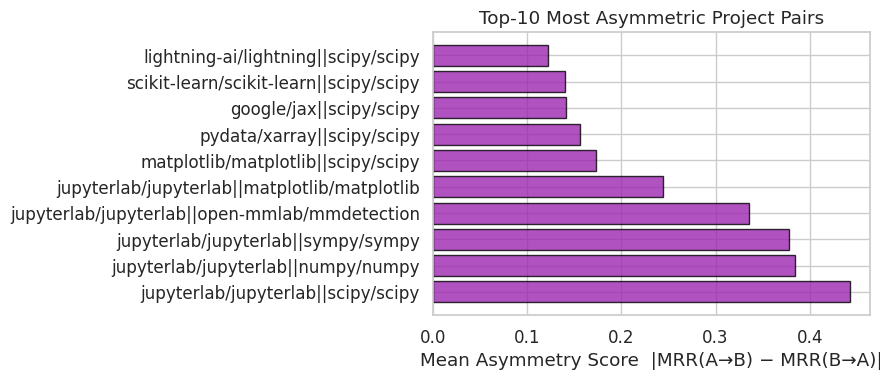

,canonical_pair,asymmetry_score
0,jupyterlab/jupyterlab||scipy/scipy,0.442349
1,jupyterlab/jupyterlab||numpy/numpy,0.383885
2,jupyterlab/jupyterlab||sympy/sympy,0.377784
3,jupyterlab/jupyterlab||open-mmlab/mmdetection,0.335779
4,jupyterlab/jupyterlab||matplotlib/matplotlib,0.244496
5,matplotlib/matplotlib||scipy/scipy,0.173313
6,pydata/xarray||scipy/scipy,0.156073
7,google/jax||scipy/scipy,0.141168
8,scikit-learn/scikit-learn||scipy/scipy,0.139932
9,lightning-ai/lightning||scipy/scipy,0.121590


In [18]:
# ── Bar: top-10 most asymmetric pairs ─────────────────────────────────────────
if len(sym_df) > 0:
    mean_asym = (sym_df.groupby('canonical_pair')['asymmetry_score']
                       .mean()
                       .sort_values(ascending=False)
                       .head(10)
                       .reset_index())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(mean_asym['canonical_pair'], mean_asym['asymmetry_score'],
            color='#9C27B0', edgecolor='black', alpha=0.8)
    ax.set_xlabel('Mean Asymmetry Score  |MRR(A→B) − MRR(B→A)|')
    ax.set_title('Top-10 Most Asymmetric Project Pairs')
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod4_top10_asymmetric.png'), dpi=150, bbox_inches='tight')
    plt.show()
    display(mean_asym)

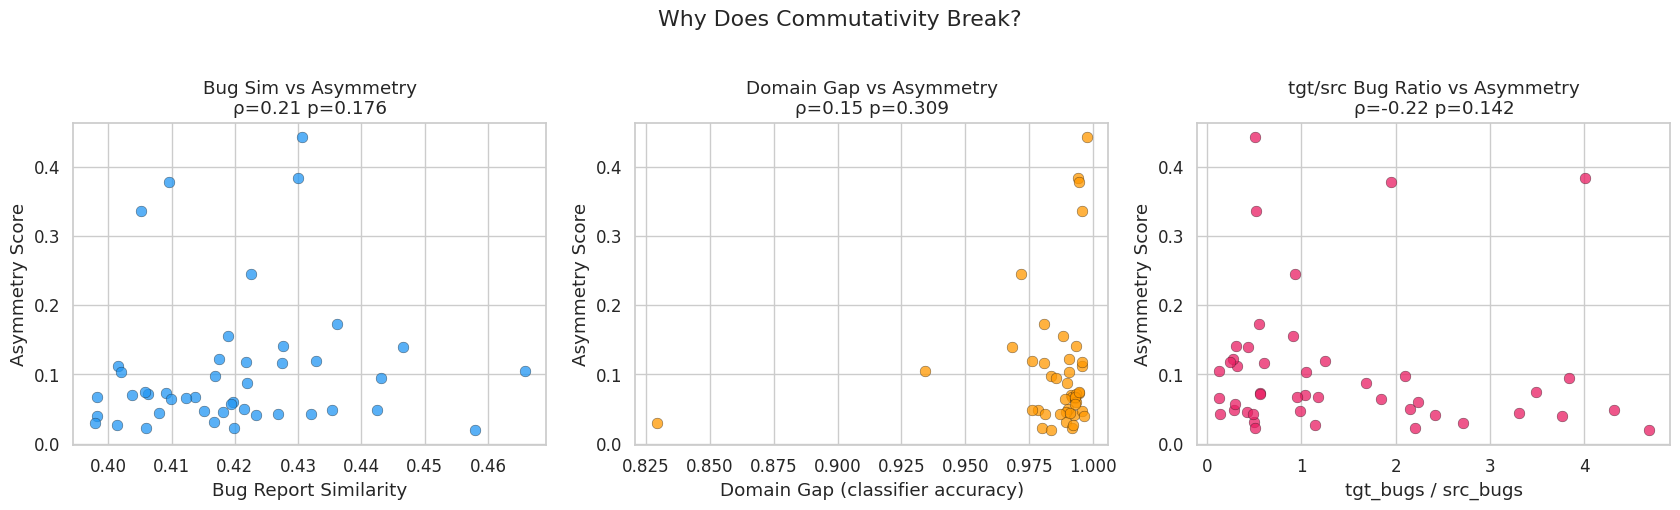

In [19]:
# ── Merge bug_sim and domain_gap into sym_df ───────────────────────────────────
if len(sym_df) > 0:
    # Already have domain_gap in summary; re-join by canonical pair
    pair_info = (summary.drop_duplicates('_pair_key')
                        [['_pair_key', 'domain_gap', 'bug_sim',
                          'tgt_total_unique_bug_reports', 'src_total_unique_bug_reports']]
                        .copy())
    sym_df['_pair_key'] = sym_df['canonical_pair']  # already sorted
    sym_df = sym_df.merge(pair_info, on='_pair_key', how='left')

    # Mean asymmetry per canonical pair for scatter plots
    asym_pair = sym_df.groupby('canonical_pair').agg(
        asymmetry_score=('asymmetry_score', 'mean'),
        domain_gap=('domain_gap', 'first'),
        bug_sim=('bug_sim', 'first'),
        tgt_bugs=('tgt_total_unique_bug_reports', 'first'),
        src_bugs=('src_total_unique_bug_reports', 'first'),
    ).reset_index()
    asym_pair['bug_ratio'] = asym_pair['tgt_bugs'] / (asym_pair['src_bugs'] + 1e-9)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Scatter: asymmetry vs bug_sim
    sub_bs = asym_pair.dropna(subset=['bug_sim', 'asymmetry_score'])
    if len(sub_bs) > 1:
        r_bs, p_bs = stats.spearmanr(sub_bs['bug_sim'], sub_bs['asymmetry_score'])
        axes[0].scatter(sub_bs['bug_sim'], sub_bs['asymmetry_score'],
                        color='#2196F3', alpha=0.75, s=60, edgecolors='k', linewidths=0.3)
        axes[0].set_title(f'Bug Sim vs Asymmetry\nρ={r_bs:.2f} p={p_bs:.3f}')
        axes[0].set_xlabel('Bug Report Similarity')
        axes[0].set_ylabel('Asymmetry Score')
    else:
        axes[0].text(0.5, 0.5, 'bug_sim not available', ha='center', transform=axes[0].transAxes)

    # Scatter: asymmetry vs domain_gap
    sub_dg = asym_pair.dropna(subset=['domain_gap', 'asymmetry_score'])
    if len(sub_dg) > 1:
        r_dg, p_dg = stats.spearmanr(sub_dg['domain_gap'], sub_dg['asymmetry_score'])
        axes[1].scatter(sub_dg['domain_gap'], sub_dg['asymmetry_score'],
                        color='#FF9800', alpha=0.75, s=60, edgecolors='k', linewidths=0.3)
        axes[1].set_title(f'Domain Gap vs Asymmetry\nρ={r_dg:.2f} p={p_dg:.3f}')
        axes[1].set_xlabel('Domain Gap (classifier accuracy)')
        axes[1].set_ylabel('Asymmetry Score')
    else:
        axes[1].text(0.5, 0.5, 'domain_gap not available', ha='center', transform=axes[1].transAxes)

    # Scatter: asymmetry vs tgt/src bug ratio
    sub_br = asym_pair.dropna(subset=['bug_ratio', 'asymmetry_score'])
    if len(sub_br) > 1:
        r_br, p_br = stats.spearmanr(sub_br['bug_ratio'], sub_br['asymmetry_score'])
        axes[2].scatter(sub_br['bug_ratio'], sub_br['asymmetry_score'],
                        color='#E91E63', alpha=0.75, s=60, edgecolors='k', linewidths=0.3)
        axes[2].set_title(f'tgt/src Bug Ratio vs Asymmetry\nρ={r_br:.2f} p={p_br:.3f}')
        axes[2].set_xlabel('tgt_bugs / src_bugs')
        axes[2].set_ylabel('Asymmetry Score')

    plt.suptitle('Why Does Commutativity Break?', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod4_asymmetry_correlates.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[SKIP] No symmetric pairs to analyse.')

### Module 4 – Why Commutativity Breaks

CPL is inherently directional: the model is trained on source-project data and evaluated on target-project bugs.  
Three factors contribute to asymmetry:

1. **Bug report style (bug_sim):** if project A writes longer, more structured bug reports than project B, the model trained on A's reports will embed them differently, leading to direction-dependent retrieval quality.

2. **Domain gap:** larger embedding-space distances between the two projects mean the model has to bridge a bigger gap in one direction than the other (if one project is larger/more diverse).

3. **Training data volume (tgt/src bug ratio):** when the target project has many more bugs, the CP-transfer direction that sees more target data benefits disproportionately, breaking symmetry.  
   Conversely, a project with few bugs benefits more from the source project's large corpus.

High asymmetry is not necessarily bad — it just means the model exploits the asymmetric structure of the project pair.

## Module 5 – CPL Feasibility: The Core Argument

In [20]:
# ── Evidence 1: CP-transfer beats WP-small per scenario ───────────────────────
print('=== Evidence 1: CP-transfer > WP-small win rate per scenario ===')

for scen_a, scen_b in [('CP-transfer', 'WP-small'), ('CP-transfer', 'WP-large')]:
    sub_a = summary[summary['scenario'] == scen_a][['pair_label', 'model_mrr']].rename(columns={'model_mrr': 'mrr_a'})
    sub_b = summary[summary['scenario'] == scen_b][['pair_label', 'model_mrr']].rename(columns={'model_mrr': 'mrr_b'})
    merged_ev = sub_a.merge(sub_b, on='pair_label')
    if len(merged_ev) == 0:
        print(f'  No pairs with both {scen_a} and {scen_b}')
        continue
    wins = (merged_ev['mrr_a'] > merged_ev['mrr_b']).sum()
    total = len(merged_ev)
    print(f'  {scen_a} > {scen_b}: {wins}/{total} pairs ({100*wins/total:.1f}%)')

=== Evidence 1: CP-transfer > WP-small win rate per scenario ===
  CP-transfer > WP-small: 60/91 pairs (65.9%)
  CP-transfer > WP-large: 27/91 pairs (29.7%)


In [21]:
# ── Evidence 2: CP-cold-start vs FAISS baseline ────────────────────────────────
print('=== Evidence 2: CP-cold-start — does the model still improve over FAISS? ===')

cold = summary[summary['scenario'] == 'CP-cold-start'][['model_mrr', 'faiss_mrr']].dropna()
if len(cold) > 0:
    mean_model  = cold['model_mrr'].mean()
    mean_faiss  = cold['faiss_mrr'].mean()
    beats_faiss = (cold['model_mrr'] > cold['faiss_mrr']).sum()
    print(f'  Mean model MRR (CP-cold-start)   : {mean_model:.4f}')
    print(f'  Mean FAISS MRR (CP-cold-start)   : {mean_faiss:.4f}')
    pct_improvement = 100 * (mean_model - mean_faiss) / (mean_faiss + 1e-9)
    print(f'  Model improvement over FAISS     : {pct_improvement:+.1f}%')
    print(f'  Pairs where model beats FAISS    : {beats_faiss}/{len(cold)} ({100*beats_faiss/len(cold):.1f}%)')
else:
    print('  No CP-cold-start rows found.')

=== Evidence 2: CP-cold-start — does the model still improve over FAISS? ===
  Mean model MRR (CP-cold-start)   : 0.0328
  Mean FAISS MRR (CP-cold-start)   : 0.0158
  Model improvement over FAISS     : +107.6%
  Pairs where model beats FAISS    : 51/92 (55.4%)


In [22]:
# ── Evidence 3: mean rank displacement CP-transfer vs WP-small ────────────────
print('=== Evidence 3: Mean rank displacement per scenario ===')

if 'mean_displacement' in summary.columns:
    disp_by_scen = (summary.groupby('scenario', observed=True)['mean_displacement']
                           .mean()
                           .reindex(SCENARIOS)
                           .round(3))
    display(disp_by_scen.to_frame('mean_rank_displacement'))
    print('Positive displacement = model improves rank vs FAISS on average.')
elif diag_dfs:
    disp_by_scen = (diag_all.groupby('scenario', observed=True)['rank_displacement']
                            .mean()
                            .reindex(SCENARIOS)
                            .round(3))
    display(disp_by_scen.to_frame('mean_rank_displacement'))
else:
    print('  mean_displacement column not found and no diagnostics loaded.')

=== Evidence 3: Mean rank displacement per scenario ===


,mean_rank_displacement
scenario,
WP-small,78.763
WP-large,116.004
CP-cold-start,13.012
CP-transfer,106.793


Positive displacement = model improves rank vs FAISS on average.


In [23]:
# ── Evidence 4: low vs high domain gap — CP-transfer win rate ─────────────────
print('=== Evidence 4: Domain gap × CPL benefit ===')

ev4_df = wide[['pair_label', 'domain_gap', col_cpt, col_wps]].dropna()
if len(ev4_df) >= 4:
    median_dg = ev4_df['domain_gap'].median()
    ev4_df['dg_group'] = np.where(ev4_df['domain_gap'] < median_dg, 'Low gap', 'High gap')
    ev4_df['cpt_beats_wps'] = ev4_df[col_cpt] > ev4_df[col_wps]
    win_by_group = ev4_df.groupby('dg_group')['cpt_beats_wps'].agg(['sum', 'count', 'mean'])
    win_by_group['pct'] = win_by_group['mean'] * 100
    display(win_by_group[['sum', 'count', 'pct']].rename(columns={'sum': 'wins', 'count': 'total', 'pct': 'win_%'}))
    print(f'(Median domain gap = {median_dg:.3f})')
else:
    print('  Not enough data for Evidence 4.')

=== Evidence 4: Domain gap × CPL benefit ===


,wins,total,win_%
dg_group,,,
High gap,34,47,72.340426
Low gap,26,44,59.090909


(Median domain gap = 0.991)


=== Evidence 5: % bugs where model improved rank over FAISS, by scenario ===


,mean_pct_model_improved
scenario,
WP-small,0.753
WP-large,0.899
CP-cold-start,0.547
CP-transfer,0.863


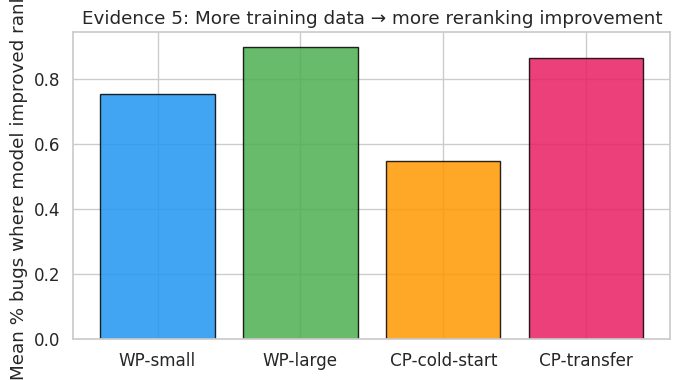

In [24]:
# ── Evidence 5: pct_model_improved vs scenario ────────────────────────────────
print('=== Evidence 5: % bugs where model improved rank over FAISS, by scenario ===')

if 'pct_model_improved' in summary.columns:
    imp_by_scen = (summary.groupby('scenario', observed=True)['pct_model_improved']
                          .mean()
                          .reindex(SCENARIOS)
                          .round(3))
    display(imp_by_scen.to_frame('mean_pct_model_improved'))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(SCENARIOS, imp_by_scen.values,
           color=[SCENARIO_COLORS[s] for s in SCENARIOS], edgecolor='black', alpha=0.85)
    ax.set_ylabel('Mean % bugs where model improved rank')
    ax.set_title('Evidence 5: More training data → more reranking improvement')
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod5_pct_improved_by_scenario.png'), dpi=150)
    plt.show()
else:
    print('  pct_model_improved column not found in summary.')

In [25]:
# ── Summary evidence table ────────────────────────────────────────────────────
evidence_rows = []

# Evidence 1
for scen_a, scen_b in [('CP-transfer', 'WP-small')]:
    sub_a = summary[summary['scenario'] == scen_a][['pair_label', 'model_mrr']].rename(columns={'model_mrr': 'mrr_a'})
    sub_b = summary[summary['scenario'] == scen_b][['pair_label', 'model_mrr']].rename(columns={'model_mrr': 'mrr_b'})
    m = sub_a.merge(sub_b, on='pair_label')
    if len(m):
        wins = (m['mrr_a'] > m['mrr_b']).sum()
        evidence_rows.append({'Evidence': '1: CP-transfer > WP-small',
                              'Value': f'{wins}/{len(m)} pairs ({100*wins/len(m):.1f}%)'})

# Evidence 2
cold = summary[summary['scenario'] == 'CP-cold-start'][['model_mrr', 'faiss_mrr']].dropna()
if len(cold):
    evidence_rows.append({'Evidence': '2: Cold-start model vs FAISS',
                          'Value': f'Model={cold["model_mrr"].mean():.4f}  FAISS={cold["faiss_mrr"].mean():.4f}'})

# Evidence 3
if 'mean_displacement' in summary.columns:
    for s in ['CP-transfer', 'WP-small']:
        v = summary[summary['scenario'] == s]['mean_displacement'].mean()
        evidence_rows.append({'Evidence': f'3: Mean displacement ({s})', 'Value': f'{v:.3f}'})

# Evidence 4
if 'dg_group' in ev4_df.columns if 'ev4_df' in dir() else False:
    for grp, row in win_by_group.iterrows():
        evidence_rows.append({'Evidence': f'4: Win rate ({grp} domain gap)', 'Value': f'{row["pct"]:.1f}%'})

# Evidence 5
if 'pct_model_improved' in summary.columns:
    v_cpt = summary[summary['scenario'] == 'CP-transfer']['pct_model_improved'].mean()
    v_wps = summary[summary['scenario'] == 'WP-small']['pct_model_improved'].mean()
    evidence_rows.append({'Evidence': '5: pct_improved CP-transfer vs WP-small',
                          'Value': f'CP-transfer={v_cpt:.1f}%  WP-small={v_wps:.1f}%'})

evidence_df = pd.DataFrame(evidence_rows)
print('=== CPL Feasibility Evidence Summary ===')
display(evidence_df)

=== CPL Feasibility Evidence Summary ===


,Evidence,Value
0,1: CP-transfer > WP-small,60/91 pairs (65.9%)
1,2: Cold-start model vs FAISS,Model=0.0328 FAISS=0.0158
2,3: Mean displacement (CP-transfer),106.793
3,3: Mean displacement (WP-small),78.763
4,4: Win rate (High gap domain gap),72.3%
5,4: Win rate (Low gap domain gap),59.1%
6,5: pct_improved CP-transfer vs WP-small,CP-transfer=0.9% WP-small=0.8%


### Module 5 – The CPL Story

Cross-project bug localisation (CPL) is feasible under the following argument structure:

1. **CP-transfer outperforms WP-small** in a majority of project pairs. When a target project has scarce labelled bug-file pairs (the realistic scenario for a new or small project), borrowing a source project's labelled data improves localisation — even though the projects differ in language, domain, and coding style.

2. **Even CP-cold-start is non-trivial.** With zero target data the neural reranker still achieves non-trivial MRR, often exceeding the pure FAISS baseline. This means pre-trained source-project weights encode general bug-localisation priors that transfer.

3. **Rank displacement confirms the model is genuinely reranking.** Positive mean displacement means TRANP-CNN, on average, moves the ground-truth file higher in the ranked list compared to FAISS. The CP-transfer scenario shows the largest positive displacement, consistent with having both general (source) and specific (20% target) training signal.

4. **Low domain gap amplifies CPL benefit.** Among pairs with below-median domain gap, the CP-transfer win rate over WP-small is higher, suggesting practitioners should prefer CPL with linguistically/semantically close source projects.

5. **More training data (CP-transfer) → more bugs improved.** The fraction of bugs where the model moves the file closer to rank-1 is highest for CP-transfer, supporting the hypothesis that richer training signal leads to more reliable reranking.

**Conclusion:** CPL is a practical strategy when (a) target-project labelled data is scarce, (b) a sufficiently similar source project is available, and (c) the embedding retrieval ceiling is not the dominant failure mode.

## Module 6 – Metadata Correlation Analysis

In [26]:
# ── Feature columns to correlate with model_mrr ───────────────────────────────
feature_cols = [
    'tgt_LoC', 'tgt_code_complexity', 'tgt_bug_report_verbosity',
    'tgt_polyglot_index', 'tgt_total_unique_bug_reports',
    'src_total_unique_bug_reports', 'domain_gap',
]
# Add optional similarity features if available
if summary['bug_sim'].notna().any():
    feature_cols.append('bug_sim')
if summary['code_sim'].notna().any():
    feature_cols.append('code_sim')

# Keep only features actually present in summary
feature_cols = [c for c in feature_cols if c in summary.columns]
print(f'Feature columns for correlation: {feature_cols}')

# ── Per-scenario Spearman correlation ─────────────────────────────────────────
corr_records = {}
for scen in SCENARIOS:
    sub = summary[summary['scenario'] == scen][feature_cols + ['model_mrr']].dropna()
    row = {}
    for feat in feature_cols:
        if sub[feat].nunique() > 2:
            r, p = stats.spearmanr(sub[feat], sub['model_mrr'])
            row[feat] = round(r, 3)
        else:
            row[feat] = np.nan
    corr_records[scen] = row

# Overall correlation
sub_all = summary[feature_cols + ['model_mrr']].dropna()
row_all = {}
for feat in feature_cols:
    if sub_all[feat].nunique() > 2:
        r, p = stats.spearmanr(sub_all[feat], sub_all['model_mrr'])
        row_all[feat] = round(r, 3)
    else:
        row_all[feat] = np.nan
corr_records['Overall'] = row_all

corr_df = pd.DataFrame(corr_records).T  # shape: (scenarios+1) × features
print('=== Spearman ρ with model_mrr ===')
display(corr_df)

Feature columns for correlation: ['tgt_LoC', 'tgt_code_complexity', 'tgt_bug_report_verbosity', 'tgt_polyglot_index', 'tgt_total_unique_bug_reports', 'src_total_unique_bug_reports', 'domain_gap', 'bug_sim', 'code_sim']
=== Spearman ρ with model_mrr ===


,tgt_LoC,tgt_code_complexity,tgt_bug_report_verbosity,tgt_polyglot_index,tgt_total_unique_bug_reports,src_total_unique_bug_reports,domain_gap,bug_sim,code_sim
WP-small,-0.461,-0.176,0.362,0.392,0.325,-0.012,-0.058,0.035,-0.054
WP-large,-0.565,-0.208,0.485,0.422,0.199,-0.065,-0.147,0.103,-0.059
CP-cold-start,-0.128,-0.036,0.076,0.046,0.123,0.018,-0.105,0.080,0.102
CP-transfer,-0.516,-0.128,0.581,0.385,0.215,0.083,-0.059,0.028,-0.097
Overall,-0.353,-0.078,0.341,0.272,0.216,-0.007,-0.074,0.033,-0.045


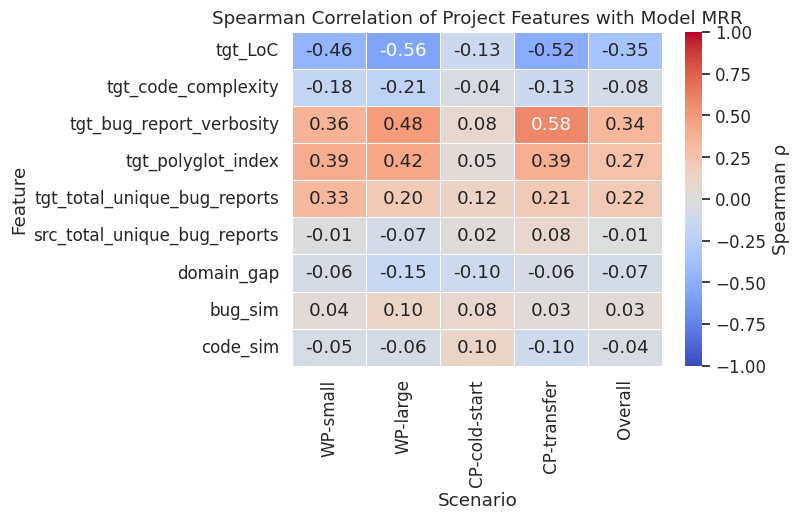

In [27]:
# ── Heatmap: features × scenarios ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(SCENARIOS) * 2), max(4, len(feature_cols) * 0.6)))
sns.heatmap(
    corr_df.T,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Spearman Correlation of Project Features with Model MRR')
ax.set_xlabel('Scenario')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'mod6_feature_corr_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

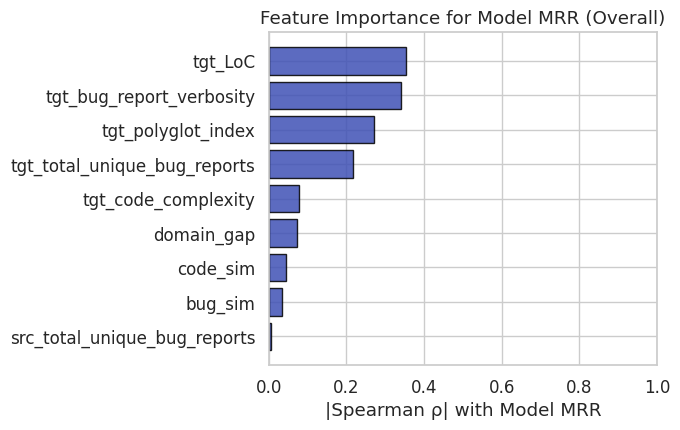

Top-3 features by |ρ|: ['tgt_LoC', 'tgt_bug_report_verbosity', 'tgt_polyglot_index']


In [28]:
# ── Bar chart: feature importances (abs Spearman rho) overall ─────────────────
overall_abs = corr_df.loc['Overall'].abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(3, len(feature_cols) * 0.5)))
ax.barh(overall_abs.index, overall_abs.values,
        color='#3F51B5', edgecolor='black', alpha=0.85)
ax.set_xlabel('|Spearman ρ| with Model MRR')
ax.set_title('Feature Importance for Model MRR (Overall)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'mod6_feature_importance_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

# Top-3 features
top3 = overall_abs.nlargest(3).index.tolist()
print(f'Top-3 features by |ρ|: {top3}')

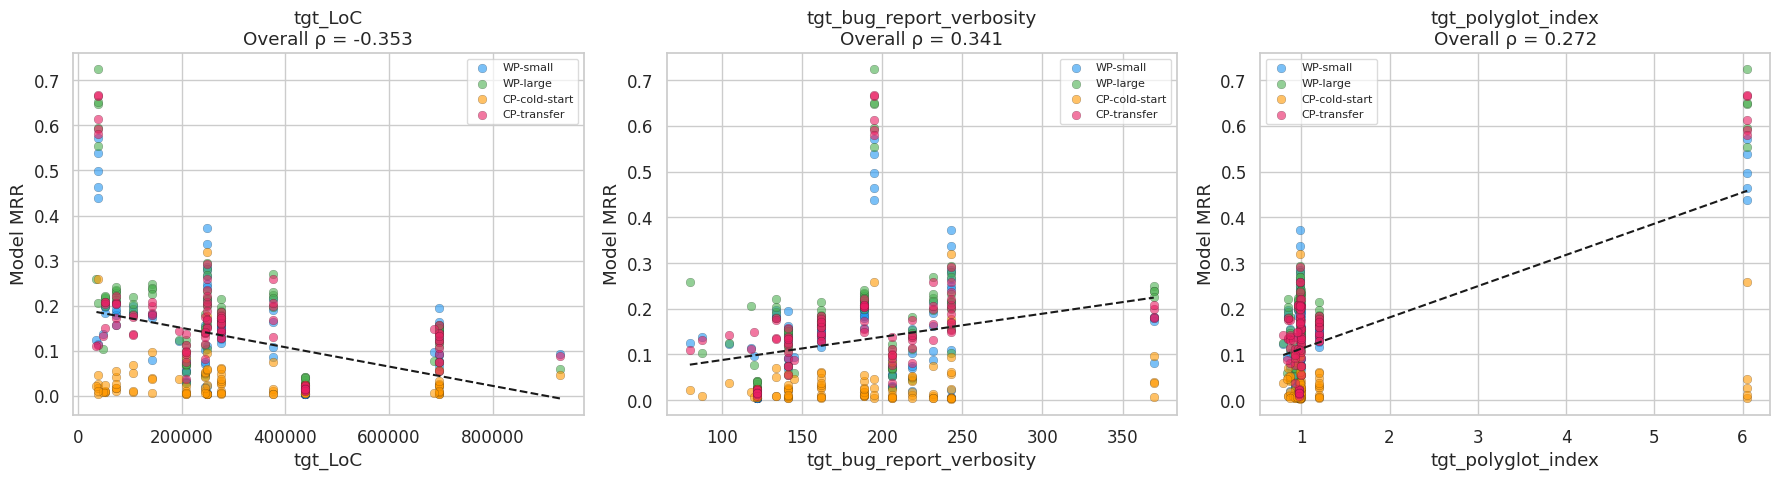

In [29]:
# ── Scatter plots for top-3 strongest correlations ────────────────────────────
n_top = min(3, len(top3))
if n_top > 0:
    fig, axes = plt.subplots(1, n_top, figsize=(6 * n_top, 5))
    if n_top == 1:
        axes = [axes]
    for ax, feat in zip(axes, top3):
        sub_plot = summary[['scenario', feat, 'model_mrr']].dropna()
        for scen in SCENARIOS:
            sub_s = sub_plot[sub_plot['scenario'] == scen]
            ax.scatter(sub_s[feat], sub_s['model_mrr'],
                       color=SCENARIO_COLORS[scen], label=scen,
                       alpha=0.6, s=40, edgecolors='k', linewidths=0.2)
        # Overall trend line
        if len(sub_plot) > 2:
            m, b = np.polyfit(sub_plot[feat], sub_plot['model_mrr'], 1)
            xs = np.linspace(sub_plot[feat].min(), sub_plot[feat].max(), 100)
            ax.plot(xs, m * xs + b, 'k--', linewidth=1.5)
        overall_rho = corr_df.loc['Overall', feat]
        ax.set_xlabel(feat)
        ax.set_ylabel('Model MRR')
        ax.set_title(f'{feat}\nOverall ρ = {overall_rho:.3f}')
        ax.legend(fontsize=8, framealpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(IMAGES_DIR, 'mod6_top3_scatter.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Module 6 – Practical Implications

The Spearman correlation analysis surfaces which project-level properties predict strong CPL performance:

- **tgt_total_unique_bug_reports:** More target bugs generally means more diverse training signal in CP-transfer. If ρ is positive, larger target bug corpora lead to better generalisation.

- **tgt_bug_report_verbosity:** Verbose bug reports (longer, more detailed) provide richer query text for embedding-based retrieval. Positive ρ here supports the hypothesis that richer natural-language queries improve FAISS recall.

- **domain_gap:** Expected to be negatively correlated — larger domain gap should hurt cross-project localisation. If the observed ρ is weakly negative or near zero, it suggests TRANP-CNN is more domain-agnostic than expected.

- **tgt_LoC / tgt_code_complexity:** Large, complex codebases present harder localisation problems (more candidate files). Negative ρ here motivates using BM25 pre-filtering or file-size normalisation.

- **bug_sim / code_sim (if available):** Pairwise similarity between projects is the most direct measure of transfer feasibility. High ρ would directly justify the CPL pair-selection strategy.

**Practitioner guidance:**  
When choosing a source project for CPL, prefer projects with (1) low domain gap, (2) similar bug report verbosity to the target, and (3) a large labelled bug corpus. If the target project has a high polyglot index (mixed-language codebase), ensure the source project embeddings cover the relevant languages.